In [1]:
import numpy as np
import matplotlib.pyplot as plt
from config import DATA_VARIANCE_SCALE

In [27]:
# ba_bounds = np.load('ba_bounds.npy')
# i_z_x = np.load('i_z_x.npy')
dv_bounds = np.load('dv_bounds.npy')
ba_bounds = np.load('ba_bound/ba_bounds.npy')


In [21]:
bounds = [ba_bounds, dv_bounds]
num_bounds_calculated = [60, 20]
bound_names = ['BA bound', 'DV bound']
final_bounds = []

for i in range(len(bounds)):
    len_training = len(bounds[i]) // num_bounds_calculated[i]
    final_bound = bounds[i] [[((j+1) * len_training - 1) for j in range(num_bounds_calculated[i])]]
    final_bound = final_bound - final_bound.mean()
    final_bounds.append(final_bound)

In [22]:
final_bounds

[array([-0.0340811 , -0.01744485,  0.04869407, -0.00498906, -0.01453805,
        -0.02165926,  0.03356695, -0.01000887, -0.05041695,  0.01535079,
        -0.04959643, -0.04530484, -0.05585736,  0.01406053, -0.00297344,
        -0.0699845 , -0.01340318, -0.05034775, -0.03868848, -0.00200495,
        -0.04267526,  0.02395385,  0.02655962,  0.0078271 ,  0.01150313,
         0.0026758 ,  0.0367218 , -0.03281039,  0.04110905,  0.08896923,
         0.02259582,  0.04647541,  0.03384823, -0.02769953,  0.03644404,
        -0.00751478,  0.01487958, -0.0217641 , -0.05519867,  0.0432739 ,
         0.02142987,  0.03287721, -0.02878887, -0.03389573,  0.05946138,
        -0.03887683,  0.06035802,  0.02097115, -0.06566119,  0.0027914 ,
        -0.01059306, -0.00827384,  0.01838943,  0.05233797, -0.02057552,
        -0.00722897,  0.00909615, -0.00646609,  0.0119997 ,  0.0511007 ]),
 array([ 0.07821345,  0.0214231 , -0.04753327,  0.08560348, -0.03701425,
        -0.01926923,  0.03701472, -0.03660035,  0

In [24]:
true_fi = 2500 * DATA_VARIANCE_SCALE**-2
true_mi = 0.5*np.log(1 + 25*true_fi)
print(f"True MI: {true_mi} | true FI: {true_fi}")

True MI: 9.433483926490393 | true FI: 6250000.0


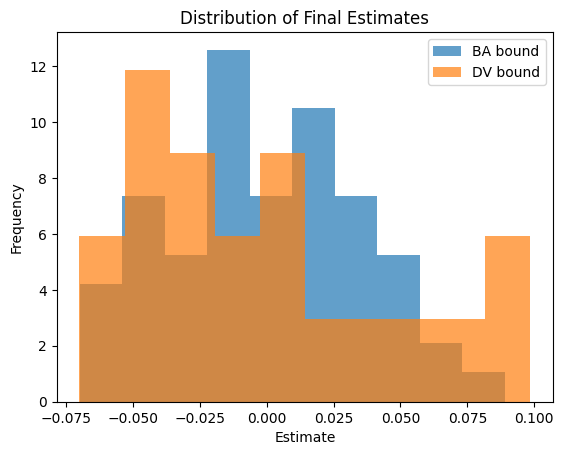

In [26]:
for i, final_bound in enumerate(final_bounds):
    plt.hist(final_bound, density=True, alpha=0.7, label=bound_names[i])
plt.xlabel('Estimate')
plt.ylabel('Frequency')
plt.title('Distribution of Final Estimates')
plt.legend()
plt.show()